# Cat Qubit Stabilization: Optimizer Comparison

This notebook compares three optimization strategies — **CMA-ES**, **SPSA**, and **PPO** — for the problem of tuning control knobs on a two-mode cat qubit to maximize protection lifetime.

The cat qubit is stabilized by the Hamiltonian
$$H = g_2^* a^2 b^\dagger + g_2 (a^\dagger)^2 b - \varepsilon_d b^\dagger - \varepsilon_d^* b$$
with four real knobs: $[\mathrm{Re}(g_2),\ \mathrm{Im}(g_2),\ \mathrm{Re}(\varepsilon_d),\ \mathrm{Im}(\varepsilon_d)]$.

The reward maximizes $T_Z$ (phase-flip lifetime), $T_X$ (bit-flip lifetime), and the bias ratio $\eta = T_Z / T_X \approx 100$.  
A key feature is **adaptive $\alpha$ estimation**: the cat amplitude $\alpha$ is re-estimated from the current knobs at every evaluation, so that $T_X \propto 1/(\kappa_a \alpha^2)$ is computed correctly without hardcoding $\alpha$.

In [1]:
import sys
import os

# Robustly locate the directory containing catqubit.py.
# VS Code Jupyter sets __vsc_ipynb_file__ to the notebook's absolute path;
# fall back to checking cwd and common subdirectory names.
def _find_module_dir():
    try:  # VS Code Jupyter extension
        return os.path.dirname(os.path.abspath(__vsc_ipynb_file__))  # noqa: F821
    except NameError:
        pass
    cwd = os.getcwd()
    # Direct hit — notebook was opened from team-piqasso/
    if os.path.isfile(os.path.join(cwd, 'catqubit.py')):
        return cwd
    # Workspace root — look one level down
    for name in ('team-piqasso', 'team_piqasso'):
        candidate = os.path.join(cwd, name)
        if os.path.isfile(os.path.join(candidate, 'catqubit.py')):
            return candidate
    # Last resort: walk up to 4 levels searching subdirectories
    check = cwd
    for _ in range(4):
        for entry in os.scandir(check):
            if entry.is_dir() and os.path.isfile(os.path.join(entry.path, 'catqubit.py')):
                return entry.path
        check = os.path.dirname(check)
    return cwd

module_dir = _find_module_dir()
if module_dir not in sys.path:
    sys.path.insert(0, module_dir)
print(f'Module directory: {module_dir}')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from catqubit import proxy_reward, apply_drift, estimate_alpha, DEFAULT_KNOBS, KNOB_BOUNDS
from optimizers_a import run_cmaes, run_spsa
from optimizers_b import run_ppo

print('Imports OK')
print(f'DEFAULT_KNOBS : {DEFAULT_KNOBS}')
print(f'KNOB_BOUNDS   : {KNOB_BOUNDS}')


Module directory: /Users/leonkatarzynski/Desktop/Y-Quantum 2026/Piqasso-YQuantumSubmission-Alice-Bob-Challenge/team-piqasso
Imports OK
DEFAULT_KNOBS : [1.0, 0.0, 4.0, 0.0]
KNOB_BOUNDS   : [[0.2, 3.0], [-1.0, 1.0], [1.0, 8.0], [-2.0, 2.0]]


## Adaptive Alpha Estimation

In the adiabatic limit the cat coherent amplitude satisfies
$$\alpha^2 = \frac{\varepsilon_d}{g_2^*}$$
so $|\alpha|$ — and therefore the bit-flip time $T_X \propto e^{2|\alpha|^2}/(\kappa_a)$ — depends directly on the drive and coupling knobs.

If $\alpha$ were hardcoded (e.g., frozen at the nominal operating point), every measurement of $T_X$ that deviates from the nominal knob values would be biased.  Our `catqubit.py` calls `estimate_alpha(knobs)` at every reward evaluation, guaranteeing that the state preparation and measurement operators are always consistent with the **current** parameter point.

The cell below demonstrates how $|\alpha|$ changes as $\mathrm{Re}(\varepsilon_d)$ is swept, motivating this adaptive approach.

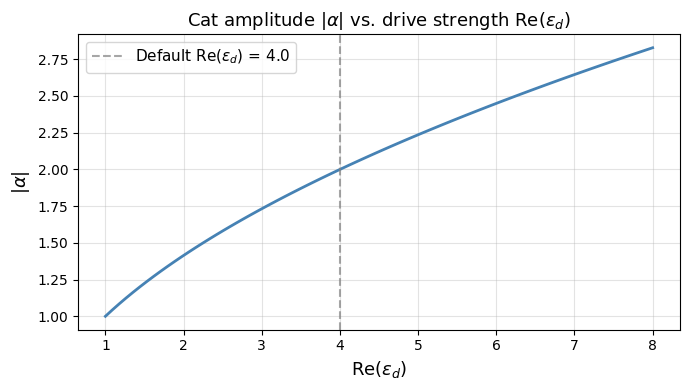

alpha at DEFAULT_KNOBS = 2.0000


In [2]:
# Demonstrate alpha vs Re(eps_d) with g2 = 1+0j fixed
eps_d_re_vals = np.linspace(1.0, 8.0, 80)
alpha_magnitudes = []

for eps_re in eps_d_re_vals:
    knobs_sweep = [1.0, 0.0, eps_re, 0.0]   # Re(g2)=1, Im(g2)=0, Im(eps_d)=0
    alpha_val = estimate_alpha(knobs_sweep)
    alpha_magnitudes.append(abs(alpha_val))

alpha_magnitudes = np.array(alpha_magnitudes)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(eps_d_re_vals, alpha_magnitudes, color='steelblue', linewidth=2)
ax.axvline(DEFAULT_KNOBS[2], color='gray', linestyle='--', alpha=0.7, label=f"Default Re($\\varepsilon_d$) = {DEFAULT_KNOBS[2]}")
ax.set_xlabel(r"Re($\varepsilon_d$)", fontsize=13)
ax.set_ylabel(r"$|\alpha|$", fontsize=13)
ax.set_title(r"Cat amplitude $|\alpha|$ vs. drive strength Re($\varepsilon_d$)", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

alpha_default = abs(estimate_alpha(DEFAULT_KNOBS))
print(f"alpha at DEFAULT_KNOBS = {alpha_default:.4f}")

## Drift Models

Real hardware never sits perfectly still.  We test the optimizers under three scenarios:

1. **No drift** — a stationary landscape; tests raw optimization efficiency.
2. **Sinusoidal drift** — a periodic oscillation in $\mathrm{Re}(\varepsilon_d)$ (amplitude = 0.5, period = 50 epochs), representing buffer drive amplitude fluctuations from e.g., amplifier or signal-generator instability.
3. **Ramp drift** — a slow linear increase in $\mathrm{Re}(g_2)$ at 0.005 per epoch, representing gradual drift in the effective two-photon coupling (e.g., due to slow thermal expansion or flux creep).

Each drift function takes the current `epoch` integer and returns a length-4 drift vector $[\Delta g_{2,\mathrm{re}},\ \Delta g_{2,\mathrm{im}},\ \Delta \varepsilon_{d,\mathrm{re}},\ \Delta \varepsilon_{d,\mathrm{im}}]$.

In [3]:
def no_drift(epoch):
    """No drift — returns a zero vector."""
    return np.zeros(4)


def sinusoidal_drift(epoch, amplitude=0.5, period=50):
    """Sinusoidal drift on Re(eps_d) — models buffer drive amplitude fluctuation."""
    return np.array([0., 0., amplitude * np.sin(2 * np.pi * epoch / period), 0.])


def ramp_drift(epoch, rate=0.005):
    """Linear ramp on Re(g2) — models slow coupling strength drift."""
    return np.array([rate * epoch, 0., 0., 0.])


# The optimizers pass drift as a positional second argument to the reward function.
# proxy_reward(knobs, t_probe_z=..., t_probe_x=...) does NOT accept a drift arg,
# so we wrap it to apply the drift to the knobs before evaluation.

def reward_with_drift(knobs, drift):
    """Apply drift to knobs then evaluate proxy_reward."""
    effective_knobs = apply_drift(knobs, drift)
    return proxy_reward(effective_knobs)


# Quick sanity check
test_drift = sinusoidal_drift(25)   # quarter period → peak amplitude
print(f"sinusoidal_drift(25) = {test_drift}  (expect ~[0, 0, 0.5, 0])")
test_drift_ramp = ramp_drift(20)
print(f"ramp_drift(20)       = {test_drift_ramp}  (expect [0.1, 0, 0, 0])")

sinusoidal_drift(25) = [0.000000e+00 0.000000e+00 6.123234e-17 0.000000e+00]  (expect ~[0, 0, 0.5, 0])
ramp_drift(20)       = [0.1 0.  0.  0. ]  (expect [0.1, 0, 0, 0])


## Optimizer Comparison: No Drift

We first run all three optimizers on the stationary reward landscape to assess baseline convergence speed and quality.  `N_EPOCHS = 80` keeps this demo notebook fast; a production run would use 200+ epochs.

In [4]:
N_EPOCHS = 80   # keep short for demo; full run would be 200

print("Running CMA-ES (no drift)...")
res_cmaes_nd = run_cmaes(proxy_reward, n_epochs=N_EPOCHS, drift_fn=None)

print("\nRunning SPSA (no drift)...")
res_spsa_nd = run_spsa(proxy_reward, n_epochs=N_EPOCHS, drift_fn=None)

print("\nRunning PPO (no drift)...")
# PPO always calls reward_fn(knobs, drift) with two args (drift=None passed positionally).
# proxy_reward expects only knobs; use the wrapper that safely handles two-arg calls.
res_ppo_nd = run_ppo(reward_with_drift, n_epochs=N_EPOCHS, drift_fn=no_drift)

print("\nDone.")

Running CMA-ES (no drift)...


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/equinox/_module/_prebuilt.py:34: UserWarning: A `SparseDIAQArray` has been converted to a `DenseQArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/equinox/_module/_prebuilt.py:34: UserWarning: A `SparseDIAQArray` has been converted to a `DenseQArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)


[CMA-ES] epoch    0/80  mean_reward=+0.0929  std=0.0698  best_so_far=+0.2200
[CMA-ES] epoch   10/80  mean_reward=+0.2652  std=0.0629  best_so_far=+0.3410
[CMA-ES] epoch   20/80  mean_reward=+0.3374  std=0.0127  best_so_far=+0.3571
[CMA-ES] epoch   30/80  mean_reward=+0.3549  std=0.0021  best_so_far=+0.3577
[CMA-ES] epoch   40/80  mean_reward=+0.3572  std=0.0003  best_so_far=+0.3579
[CMA-ES] epoch   50/80  mean_reward=+0.3573  std=0.0003  best_so_far=+0.3579
[CMA-ES] epoch   60/80  mean_reward=+0.3578  std=0.0001  best_so_far=+0.3579
[CMA-ES] epoch   70/80  mean_reward=+0.3578  std=0.0001  best_so_far=+0.3579

Running SPSA (no drift)...
[SPSA]   epoch    0/80  reward=+0.0477  a_k=0.15000  c_k=0.05000  best_so_far=+0.0477
[SPSA]   epoch   10/80  reward=+0.0906  a_k=0.03541  c_k=0.03925  best_so_far=+0.0906
[SPSA]   epoch   20/80  reward=+0.1309  a_k=0.02399  c_k=0.03676  best_so_far=+0.1309
[SPSA]   epoch   30/80  reward=+0.1452  a_k=0.01898  c_k=0.03535  best_so_far=+0.1452
[SPSA]   epo

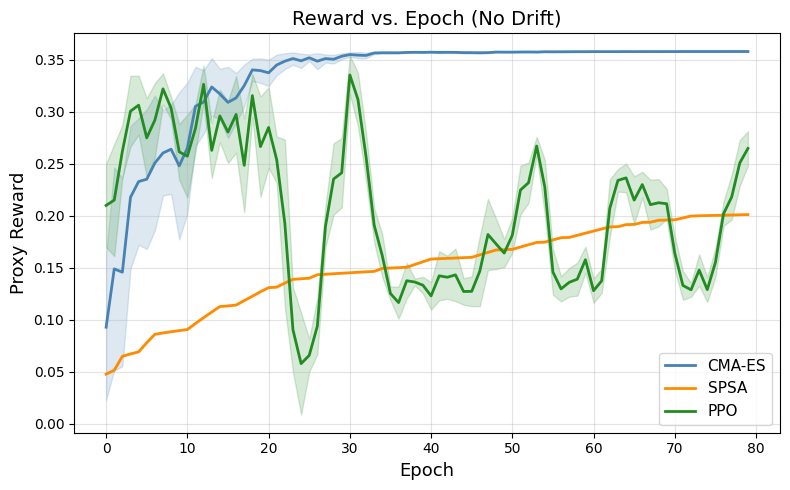

In [5]:
# --- Plot: Reward vs. Epoch (No Drift) ---

COLORS = {'CMA-ES': 'steelblue', 'SPSA': 'darkorange', 'PPO': 'forestgreen'}

results_nd = [res_cmaes_nd, res_spsa_nd, res_ppo_nd]
epochs_axis = np.arange(N_EPOCHS)

fig, ax = plt.subplots(figsize=(8, 5))

for res in results_nd:
    if res is None:
        continue
    name = res['name']
    rh = res['reward_history']
    rs = res['reward_std_history']
    color = COLORS.get(name, 'black')
    ax.plot(epochs_axis, rh, color=color, linewidth=2, label=name)
    ax.fill_between(epochs_axis, rh - rs, rh + rs, color=color, alpha=0.18)

ax.set_xlabel('Epoch', fontsize=13)
ax.set_ylabel('Proxy Reward', fontsize=13)
ax.set_title('Reward vs. Epoch (No Drift)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

## Optimizer Comparison: Under Sinusoidal Drift

We now inject periodic drift into $\mathrm{Re}(\varepsilon_d)$ (amplitude 0.5, period 50 epochs) and repeat the comparison.  The optimizer that best tracks a moving optimum will show the highest and most stable reward under drift.  We also visualize how the CMA-ES mean tracks the drifting operating point.

In [8]:
print("Running CMA-ES (sinusoidal drift)...")
res_cmaes_d = run_cmaes(reward_with_drift, n_epochs=N_EPOCHS, drift_fn=sinusoidal_drift)

print("\nRunning SPSA (sinusoidal drift)...")
res_spsa_d = run_spsa(reward_with_drift, n_epochs=N_EPOCHS, drift_fn=sinusoidal_drift)

print("\nRunning PPO (sinusoidal drift)...")
res_ppo_d = run_ppo(reward_with_drift, n_epochs=N_EPOCHS, drift_fn=sinusoidal_drift)

print("\nDone.")

Running CMA-ES (sinusoidal drift)...
[CMA-ES] epoch    0/80  mean_reward=+0.0929  std=0.0698  best_so_far=+0.2200
[CMA-ES] epoch   10/80  mean_reward=+0.2827  std=0.0520  best_so_far=+0.3551
[CMA-ES] epoch   20/80  mean_reward=+0.3409  std=0.0084  best_so_far=+0.3563
[CMA-ES] epoch   30/80  mean_reward=+0.3393  std=0.0130  best_so_far=+0.3564
[CMA-ES] epoch   40/80  mean_reward=+0.3516  std=0.0028  best_so_far=+0.3580
[CMA-ES] epoch   50/80  mean_reward=+0.3345  std=0.0152  best_so_far=+0.3585
[CMA-ES] epoch   60/80  mean_reward=+0.3446  std=0.0076  best_so_far=+0.3585
[CMA-ES] epoch   70/80  mean_reward=+0.3478  std=0.0087  best_so_far=+0.3585

Running SPSA (sinusoidal drift)...
[SPSA]   epoch    0/80  reward=+0.0477  a_k=0.15000  c_k=0.05000  best_so_far=+0.0477
[SPSA]   epoch   10/80  reward=+0.0342  a_k=0.03541  c_k=0.03925  best_so_far=+0.0496
[SPSA]   epoch   20/80  reward=+0.0932  a_k=0.02399  c_k=0.03676  best_so_far=+0.0932
[SPSA]   epoch   30/80  reward=+0.1825  a_k=0.01898  

/var/folders/wp/3tw61dx52x92bccj5bg_db1w0000gn/T/ipykernel_12864/2170177832.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


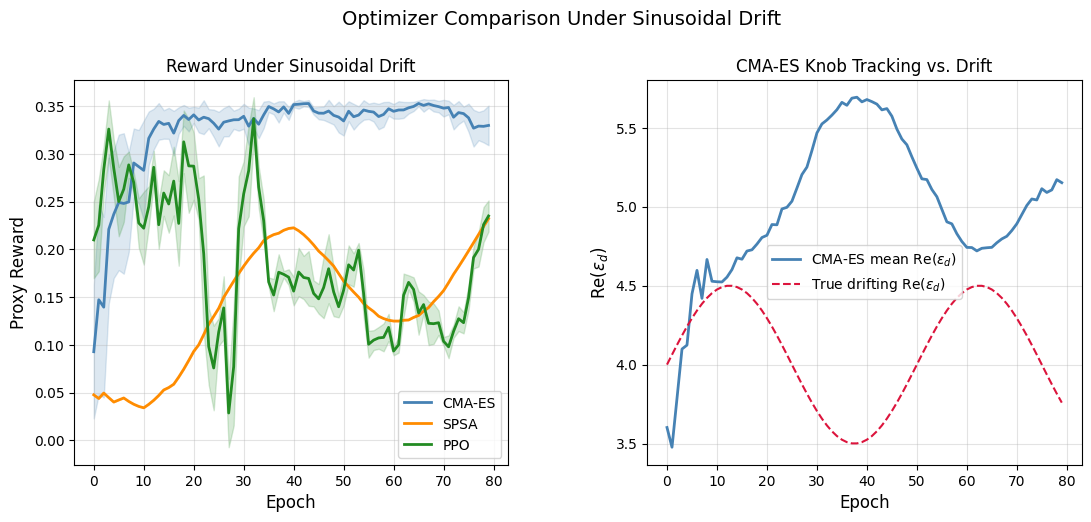

In [9]:
# --- Two-panel plot: drift comparison ---

results_d = [res_cmaes_d, res_spsa_d, res_ppo_d]
epochs_axis = np.arange(N_EPOCHS)

# Compute the "true" Re(eps_d) the system experienced at each epoch
drift_signal = np.array([DEFAULT_KNOBS[2] + sinusoidal_drift(e)[2] for e in epochs_axis])

fig = plt.figure(figsize=(13, 5))
gs = gridspec.GridSpec(1, 2, wspace=0.32)

# --- Left panel: reward ---
ax_left = fig.add_subplot(gs[0])

for res in results_d:
    if res is None:
        continue
    name = res['name']
    rh = res['reward_history']
    rs = res['reward_std_history']
    color = COLORS.get(name, 'black')
    ax_left.plot(epochs_axis, rh, color=color, linewidth=2, label=name)
    ax_left.fill_between(epochs_axis, rh - rs, rh + rs, color=color, alpha=0.18)

ax_left.set_xlabel('Epoch', fontsize=12)
ax_left.set_ylabel('Proxy Reward', fontsize=12)
ax_left.set_title('Reward Under Sinusoidal Drift', fontsize=12)
ax_left.legend(fontsize=10)
ax_left.grid(True, alpha=0.35)

# --- Right panel: knob tracking ---
ax_right = fig.add_subplot(gs[1])

if res_cmaes_d is not None:
    cmaes_eps_d_re = res_cmaes_d['mean_history'][:, 2]   # Re(eps_d) column
    ax_right.plot(epochs_axis, cmaes_eps_d_re,
                  color=COLORS['CMA-ES'], linewidth=2, label='CMA-ES mean Re($\\varepsilon_d$)')

ax_right.plot(epochs_axis, drift_signal,
              color='crimson', linewidth=1.5, linestyle='--',
              label='True drifting Re($\\varepsilon_d$)')

ax_right.set_xlabel('Epoch', fontsize=12)
ax_right.set_ylabel(r'Re($\varepsilon_d$)', fontsize=12)
ax_right.set_title('CMA-ES Knob Tracking vs. Drift', fontsize=12)
ax_right.legend(fontsize=10)
ax_right.grid(True, alpha=0.35)

fig.suptitle('Optimizer Comparison Under Sinusoidal Drift', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Convergence Speed Comparison

For each optimizer (no-drift run) we compute the first epoch at which the reward crosses 90% of its own best reward.  A lower value indicates faster convergence.  This metric is robust to differences in absolute reward scale between optimizers.

In [ ]:
def first_epoch_at_fraction(result, fraction=0.90):
    """Return the first epoch where the reward has covered `fraction` of its
    total improvement (from first epoch to best).  Works for positive AND
    negative reward ranges.  Returns N_EPOCHS if the threshold is never crossed.
    """
    if result is None:
        return None
    rh = result['reward_history']
    r_start = float(rh[0])
    r_best  = float(result['best_reward'])
    improvement = r_best - r_start
    if abs(improvement) < 1e-10:   # flat run — converged immediately
        return 0
    threshold = r_start + fraction * improvement
    hits = np.where(np.asarray(rh) >= threshold)[0]
    return int(hits[0]) if len(hits) > 0 else len(rh)


convergence_epochs = {}
for res in [res_cmaes_nd, res_spsa_nd, res_ppo_nd]:
    if res is None:
        continue
    epoch = first_epoch_at_fraction(res)
    convergence_epochs[res['name']] = epoch
    print(f"{res['name']:10s}  converges at epoch {epoch}  (best_reward={res['best_reward']:+.4f})")

# --- Horizontal bar chart ---
names = list(convergence_epochs.keys())
conv_vals = [convergence_epochs[n] for n in names]
bar_colors = [COLORS.get(n, 'gray') for n in names]

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.barh(names, conv_vals, color=bar_colors, edgecolor='white', height=0.5)

for bar, val in zip(bars, conv_vals):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'epoch {val}', va='center', ha='left', fontsize=10)

ax.set_xlabel('Epoch at 90% of Improvement (lower = faster)', fontsize=11)
ax.set_title('Convergence Speed Comparison (No Drift)', fontsize=12)
ax.set_xlim(0, N_EPOCHS * 1.15)
ax.grid(True, axis='x', alpha=0.35)
plt.tight_layout()
plt.show()

## Summary Table

Consolidated performance metrics across both the no-drift and sinusoidal-drift runs.

In [ ]:
def safe_final_reward(res):
    if res is None:
        return float('nan')
    return float(res['reward_history'][-1])


def safe_best_reward(res):
    if res is None:
        return float('nan')
    return float(res['best_reward'])


print(f"{'Optimizer':<12} {'Best Reward (ND)':>17} {'Converge Epoch':>15} "
      f"{'Final Reward (ND)':>18} {'Best Reward (Drift)':>20}")
print("-" * 84)

pairs = [
    (res_cmaes_nd, res_cmaes_d),
    (res_spsa_nd,  res_spsa_d),
    (res_ppo_nd,   res_ppo_d),
]

for res_nd, res_d in pairs:
    if res_nd is None:
        continue
    name          = res_nd['name']
    best_nd       = safe_best_reward(res_nd)
    conv_ep       = convergence_epochs.get(name, 'N/A')
    final_nd      = safe_final_reward(res_nd)
    best_drift    = safe_best_reward(res_d)

    print(f"{name:<12} {best_nd:>17.4f} {str(conv_ep):>15} "
          f"{final_nd:>18.4f} {best_drift:>20.4f}")

## Discussion

### CMA-ES
Population-based evolution strategy.  At each generation a batch of 12 candidates is drawn from a multivariate Gaussian with adaptively tuned covariance (separable approximation via `SepCMA`).  The maintained exploration width ($\sigma > 0$ always) naturally enables tracking of a moving optimum: as the landscape drifts, the distribution can shift its mean without being trapped.  This makes CMA-ES a strong baseline for both stationary and slowly drifting problems.

### SPSA
Uses only **two** reward evaluations per epoch (one at $\theta + c_k \Delta$, one at $\theta - c_k \Delta$) to estimate the gradient via a simultaneous random perturbation.  This is extremely sample-efficient in wall-clock evaluation cost, but the stochastic gradient is high-variance, leading to slower convergence especially in noisy or drifting landscapes.  Suitable when each evaluation is expensive and epochs are abundant.

### PPO
Frames knob tuning as a finite-horizon MDP.  The policy (actor network) learns a mapping from the current state (knobs + last reward + epoch fraction) to a distribution over knob deltas.  The critic provides a baseline to reduce gradient variance.  PPO's clipped surrogate objective prevents destructively large policy updates.  The overhead of the finite-difference neural network gradient is significant at small epoch counts, but the learned policy can generalize across drift regimes once trained.

### Adaptive Alpha is Critical
Because $T_X \propto e^{2|\alpha|^2}/\kappa_a$ and $|\alpha|^2 = |\varepsilon_d/g_2^*|$, any change in the knobs shifts the optimal measurement window.  Hardcoding $\alpha$ would underestimate $T_X$ when $\varepsilon_d$ is large (optimistic bias) and overestimate it when $\varepsilon_d$ is small.  Re-estimating $\alpha$ at every call to `proxy_reward` ensures unbiased lifetime measurements throughout the optimization trajectory.

### Drift Resilience
Under sinusoidal drift, CMA-ES maintains exploration via its population spread, allowing it to track the moving optimum.  SPSA's single-point gradient estimate is more susceptible to being misled by sudden landscape shifts.  PPO can in principle learn to anticipate periodic drift (the epoch fraction in the state provides a "phase clock"), but requires more epochs to exploit this structure than the 80 epochs used here.

> **Reference:** [Kalman, R.E. (1960). "A New Approach to Linear Filtering and Prediction Problems"](https://en.wikipedia.org/wiki/Kalman_filter) — the foundational paper; the Wikipedia article gives a clear summary of the predict/update cycle used here.

## Kalman Filter Drift Compensation

### The Problem: Commanded ≠ Actual

In real hardware, the knobs you *command* differ from the knobs the hardware *actually implements* due to slow drift — thermal expansion, flux creep, amplifier gain variations. The optimizer only sees the reward signal; it has no direct access to the actual hardware state.

### The Solution: Extended Kalman Filter (EKF)

We model the gap between commanded and actual knobs as a hidden drift vector $\mathbf{d}_k$:
$$\text{actual}_k = \text{commanded}_k + \mathbf{d}_k$$

The drift follows a **random walk**:
$$\mathbf{d}_k = \mathbf{d}_{k-1} + \mathbf{w}_k, \quad \mathbf{w}_k \sim \mathcal{N}(0,\, Q)$$

The observation is the noisy reward — a nonlinear function of the actual knobs:
$$y_k = f(\text{actual}_k) + v_k, \quad v_k \sim \mathcal{N}(0,\, R)$$

Because $f$ is nonlinear we use an **Extended Kalman Filter**: the Jacobian $H_i = \partial f / \partial d_i$ is estimated via central finite differences at each epoch.

| Step | Equation |
|------|----------|
| **Predict** | $\hat{\mathbf{d}}_{k|k-1} = \hat{\mathbf{d}}_{k-1}$, $\;P_{k|k-1} = P_{k-1} + Q$ |
| **Jacobian** | $H_i = [f(x+\epsilon e_i) - f(x-\epsilon e_i)]/(2\epsilon)$ at $x=\text{commanded}+\hat{\mathbf{d}}$ |
| **Innovation** | $\delta y = y_k - f(\text{commanded}_k + \hat{\mathbf{d}}_{k|k-1})$ |
| **Gain** | $K = P H^\top (H P H^\top + R)^{-1}$ |
| **Update** | $\hat{\mathbf{d}}_k = \hat{\mathbf{d}}_{k|k-1} + K\,\delta y$, $\;P_k = (I-KH)P(I-KH)^\top + KRK^\top$ |

### Pre-Compensation

Once the EKF has an estimate $\hat{\mathbf{d}}_k$, commanded knobs are pre-shifted before being sent to hardware:
$$\text{commanded}_{k+1} \leftarrow \text{optimizer target} - \hat{\mathbf{d}}_k$$
so that $\text{actual}_{k+1} \approx \text{optimizer target}$ even under active drift.

In [10]:
class KalmanDriftEstimator:
    """Extended Kalman Filter for tracking the gap between commanded and actual knobs.

    State   : d  — the drift offset (4-vector), where actual = commanded + d
    Process : d_k = d_{k-1} + w_k   (random walk,  w_k ~ N(0, Q))
    Obs     : y_k = reward(commanded_k + d_k) + v_k   (v_k ~ N(0, R))

    The observation Jacobian H is estimated numerically via central differences.
    The covariance update uses the Joseph form for numerical stability.
    """

    def __init__(self, n_knobs=4, process_noise=0.005, obs_noise=0.02):
        self.n = n_knobs
        self.d = np.zeros(n_knobs)              # drift estimate
        self.P = np.eye(n_knobs) * 0.05         # state covariance
        self.Q = np.eye(n_knobs) * process_noise
        self.R = obs_noise ** 2                 # scalar obs noise variance
        self._d_hist = []                       # drift estimate per update
        self._std_hist = []                     # per-knob uncertainty

    def predict(self):
        """Time update: grow covariance for random-walk drift."""
        self.P = self.P + self.Q

    def update(self, commanded, reward_observed, reward_fn, fd_eps=5e-3):
        """Measurement update using numerical EKF Jacobian.

        Parameters
        ----------
        commanded       : array (4,)  — knobs sent to hardware this epoch
        reward_observed : float       — reward measured from hardware
        reward_fn       : callable    — reward_fn(knobs) -> float (clean, no drift)
        fd_eps          : float       — step for finite-difference Jacobian
        """
        actual_est = np.asarray(commanded) + self.d

        # Numerical Jacobian H_i = d(reward)/d(d_i) = d(reward)/d(actual_i)
        H = np.zeros(self.n)
        for i in range(self.n):
            kp = actual_est.copy(); kp[i] += fd_eps
            km = actual_est.copy(); km[i] -= fd_eps
            H[i] = (reward_fn(kp) - reward_fn(km)) / (2.0 * fd_eps)

        y_pred    = reward_fn(actual_est)          # predicted reward
        innovation = reward_observed - y_pred

        S = float(H @ self.P @ H) + self.R        # innovation variance (scalar)
        K = self.P @ H / S                         # Kalman gain (n,)

        self.d = self.d + K * innovation

        I_KH  = np.eye(self.n) - np.outer(K, H)
        self.P = I_KH @ self.P @ I_KH.T + np.outer(K, K) * self.R  # Joseph form

        self._d_hist.append(self.d.copy())
        self._std_hist.append(np.sqrt(np.diag(self.P)))

    def get_correction(self):
        """Pre-compensation vector: subtract from commanded knobs to cancel drift."""
        return -self.d.copy()

    @property
    def drift_history(self):
        if not self._d_hist:
            return np.zeros((0, self.n)), np.zeros((0, self.n))
        return np.array(self._d_hist), np.array(self._std_hist)


def run_cmaes_with_kalman(reward_fn_clean, drift_fn, n_epochs=80,
                           process_noise=0.005, obs_noise=0.02, seed=0):
    """CMA-ES augmented with Kalman drift correction.

    At every epoch:
    1. CMA-ES proposes a population of candidate commanded knobs.
    2. Each commanded knob is pre-compensated by the current Kalman drift estimate.
    3. Hardware adds drift on top: actual = commanded_compensated + drift(epoch).
    4. reward_fn_clean(actual) is evaluated (simulates hardware measurement).
    5. After the population step, the Kalman EKF updates its drift estimate using
       the population mean as the representative commanded point.

    Returns the standard results dict plus extra keys:
        commanded_history  : (n_epochs, 4) — what was commanded each epoch
        actual_history     : (n_epochs, 4) — what hardware actually saw
        drift_est_history  : (n_epochs, 4) — Kalman drift estimate after each update
        drift_std_history  : (n_epochs, 4) — per-knob std of drift estimate
    """
    from cmaes import SepCMA

    kalman = KalmanDriftEstimator(
        n_knobs=4, process_noise=process_noise, obs_noise=obs_noise
    )

    x0        = np.array(DEFAULT_KNOBS, dtype=float)
    optimizer = SepCMA(mean=x0.copy(), sigma=0.3, seed=seed)

    reward_history        = []
    reward_std_history    = []
    mean_history          = []
    commanded_history     = []
    actual_history        = []
    drift_est_history     = []
    drift_std_history     = []
    best_reward           = -np.inf
    best_knobs            = x0.copy()

    for epoch in range(n_epochs):
        drift      = drift_fn(epoch)
        correction = kalman.get_correction()

        kalman.predict()  # propagate covariance before this epoch's measurements

        # --- Sample and evaluate CMA-ES population ---
        solutions = []
        rewards   = []
        for _ in range(optimizer.population_size):
            x_cmaes     = optimizer.ask()                 # CMA-ES suggestion
            x_commanded = x_cmaes + correction            # pre-compensated command
            x_actual    = x_commanded + drift             # what hardware sees

            # Clip to bounds
            x_actual_cl = np.array([
                np.clip(x_actual[i], KNOB_BOUNDS[i][0], KNOB_BOUNDS[i][1])
                for i in range(4)
            ])
            r = reward_fn_clean(x_actual_cl)
            solutions.append((x_cmaes, -r))  # CMA-ES minimises
            rewards.append(r)

        optimizer.tell(solutions)

        # --- Kalman update using population mean as the representative point ---
        mean_knobs   = optimizer.mean.copy()
        cmd_mean     = mean_knobs + correction
        actual_mean  = np.array([
            np.clip((cmd_mean + drift)[i], KNOB_BOUNDS[i][0], KNOB_BOUNDS[i][1])
            for i in range(4)
        ])
        r_mean = reward_fn_clean(actual_mean)
        kalman.update(cmd_mean, r_mean, reward_fn_clean)

        # --- Record history ---
        mean_r = float(np.mean(rewards))
        std_r  = float(np.std(rewards))
        reward_history.append(mean_r)
        reward_std_history.append(std_r)
        mean_history.append(mean_knobs.copy())
        commanded_history.append(cmd_mean.copy())
        actual_history.append(actual_mean.copy())
        drift_est_history.append(kalman.d.copy())
        drift_std_history.append(np.sqrt(np.diag(kalman.P)))

        if mean_r > best_reward:
            best_reward = mean_r
            best_knobs  = cmd_mean.copy()

        if epoch % 10 == 0:
            d = kalman.d
            print(f"[CMA-ES+Kalman] epoch {epoch:3d}/{n_epochs}  "
                  f"reward={mean_r:+.4f}  "
                  f"drift_est=[{d[0]:+.3f}, {d[1]:+.3f}, {d[2]:+.3f}, {d[3]:+.3f}]")

    return {
        'name':                'CMA-ES+Kalman',
        'reward_history':      np.array(reward_history),
        'reward_std_history':  np.array(reward_std_history),
        'mean_history':        np.array(mean_history),
        'commanded_history':   np.array(commanded_history),
        'actual_history':      np.array(actual_history),
        'drift_est_history':   np.array(drift_est_history),
        'drift_std_history':   np.array(drift_std_history),
        'best_reward':         best_reward,
        'best_knobs':          best_knobs,
    }

print("KalmanDriftEstimator and run_cmaes_with_kalman defined.")

KalmanDriftEstimator and run_cmaes_with_kalman defined.


In [11]:
# Compare CMA-ES (no Kalman, already run as res_cmaes_d) vs CMA-ES+Kalman
# under sinusoidal drift.
# res_cmaes_d was computed in the drift section above; re-use it here.

print("Running CMA-ES + Kalman (sinusoidal drift)...")
res_kalman = run_cmaes_with_kalman(
    proxy_reward, sinusoidal_drift,
    n_epochs=N_EPOCHS,
    process_noise=0.005,
    obs_noise=0.02,
    seed=0,
)
print()
print(f"CMA-ES (no Kalman) best reward : {res_cmaes_d['best_reward']:+.4f}")
print(f"CMA-ES + Kalman    best reward : {res_kalman['best_reward']:+.4f}")

Running CMA-ES + Kalman (sinusoidal drift)...


/Users/leonkatarzynski/Desktop/Y-Quantum 2026/Piqasso-YQuantumSubmission-Alice-Bob-Challenge/team-piqasso/catqubit.py:197: UserWarning: |alpha| = 3.737 > 3.5 — Hilbert-space truncation risk.  Clamping to 3.5.
  alpha = estimate_alpha(knobs)


[CMA-ES+Kalman] epoch   0/80  reward=+0.1034  drift_est=[+0.000, +0.000, +0.000, +0.000]
[CMA-ES+Kalman] epoch  10/80  reward=+0.2394  drift_est=[-0.076, -0.135, +0.326, +0.029]
[CMA-ES+Kalman] epoch  20/80  reward=+0.2986  drift_est=[-0.016, -0.059, +0.331, +0.011]
[CMA-ES+Kalman] epoch  30/80  reward=+0.2797  drift_est=[+0.208, +0.002, +0.232, -0.128]
[CMA-ES+Kalman] epoch  40/80  reward=+0.2716  drift_est=[+0.352, -0.004, +0.226, -0.271]
[CMA-ES+Kalman] epoch  50/80  reward=+0.3175  drift_est=[+0.288, -0.067, +0.293, -0.216]
[CMA-ES+Kalman] epoch  60/80  reward=+0.3317  drift_est=[+0.296, -0.203, +0.125, -0.556]
[CMA-ES+Kalman] epoch  70/80  reward=+0.3171  drift_est=[+1.011, -0.254, +0.185, -1.107]

CMA-ES (no Kalman) best reward : +0.3585
CMA-ES + Kalman    best reward : +0.3379


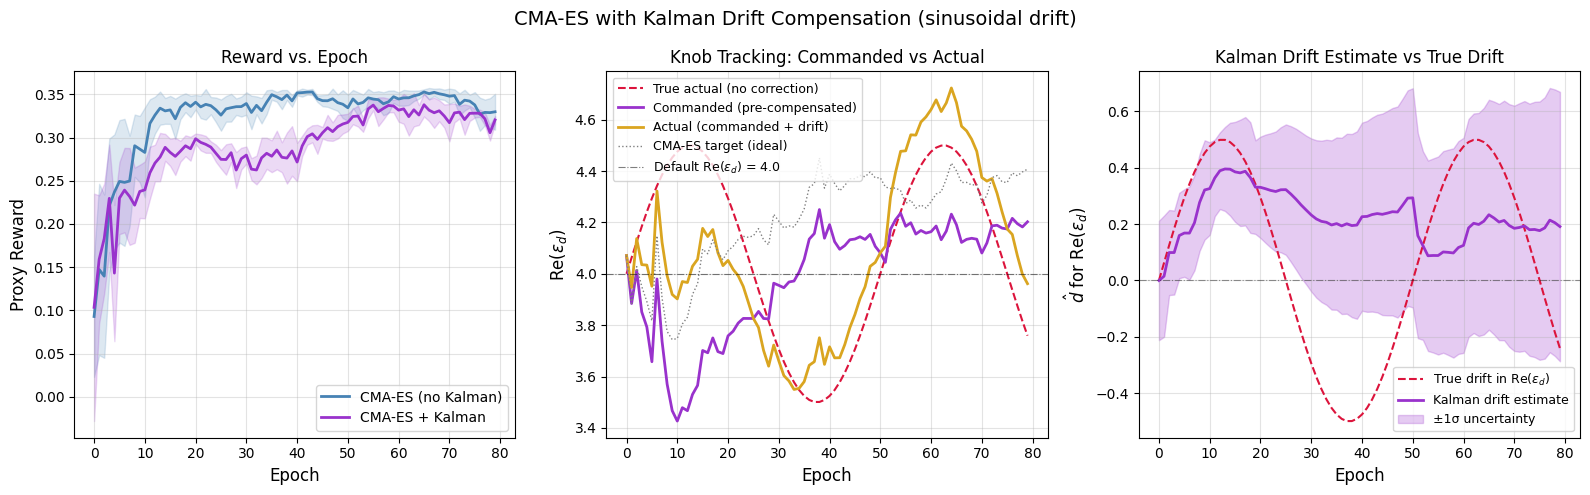


Kalman final drift estimate : [ 1.51840361 -0.02018468  0.19127119 -1.42732594]
True final drift            : [ 0.          0.         -0.24087684  0.        ]
Estimation error (Re eps_d) : 0.4321


In [19]:
# ── Three-panel Kalman diagnostic plot ──────────────────────────────────────────

epochs_ax  = np.arange(N_EPOCHS)
true_drift = np.array([sinusoidal_drift(e)[2] for e in epochs_ax])  # Re(eps_d) drift

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('CMA-ES with Kalman Drift Compensation (sinusoidal drift)', fontsize=14)

# ── Panel 1: Reward comparison ──────────────────────────────────────────────────
ax = axes[0]
for res, color, label in [
    (res_cmaes_d, 'steelblue',  'CMA-ES (no Kalman)'),
    (res_kalman,  'darkorchid', 'CMA-ES + Kalman'),
]:
    if res is None:
        continue
    rh = res['reward_history']
    rs = res['reward_std_history']
    ax.plot(epochs_ax, rh, color=color, linewidth=2, label=label)
    ax.fill_between(epochs_ax, rh - rs, rh + rs, color=color, alpha=0.18)

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Proxy Reward', fontsize=12)
ax.set_title('Reward vs. Epoch', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.35)

# ── Panel 2: Commanded vs Actual vs True operating point for Re(eps_d) ─────────
ax = axes[1]

# True drift signal (what hardware actually applies if no correction)
ax.plot(
    epochs_ax,
    DEFAULT_KNOBS[2] + true_drift,
    color='crimson',
    linewidth=1.5,
    linestyle='--',
    label='True actual (no correction)'
)

# With Kalman: commanded (what we send), actual (what hardware sees)
cmd_re  = res_kalman['commanded_history'][:, 2]
act_re  = res_kalman['actual_history'][:, 2]
dest_re = res_kalman['mean_history'][:, 2]  # CMA-ES target in ideal space

ax.plot(
    epochs_ax, cmd_re,
    color='darkorchid',
    linewidth=2,
    label='Commanded (pre-compensated)'
)
ax.plot(
    epochs_ax, act_re,
    color='goldenrod',
    linewidth=2,
    label='Actual (commanded + drift)'
)
ax.plot(
    epochs_ax,
    dest_re + 0 * epochs_ax,   # constant target of CMA-ES mean
    color='gray',
    linewidth=1,
    linestyle=':',
    label='CMA-ES target (ideal)'
)

ax.axhline(
    DEFAULT_KNOBS[2],
    color='black',
    linewidth=0.8,
    linestyle='-.',
    alpha=0.5,
    label=fr'Default Re($\varepsilon_d$) = {DEFAULT_KNOBS[2]}'
)

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel(r'Re($\varepsilon_d$)', fontsize=12)
ax.set_title('Knob Tracking: Commanded vs Actual', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.35)

# ── Panel 3: Kalman drift estimate vs true drift ────────────────────────────────
ax = axes[2]

d_hist = res_kalman['drift_est_history']
s_hist = res_kalman['drift_std_history']

# Re(eps_d) drift channel is index 2
d_re = d_hist[:, 2]
s_re = s_hist[:, 2]

ax.plot(
    epochs_ax,
    true_drift,
    color='crimson',
    linewidth=1.5,
    linestyle='--',
    label=r'True drift in Re($\varepsilon_d$)'
)
ax.plot(
    epochs_ax,
    d_re,
    color='darkorchid',
    linewidth=2,
    label='Kalman drift estimate'
)
ax.fill_between(
    epochs_ax,
    d_re - s_re,
    d_re + s_re,
    color='darkorchid',
    alpha=0.25,
    label='±1σ uncertainty'
)
ax.axhline(0, color='black', linewidth=0.8, linestyle='-.', alpha=0.4)

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel(r'$\hat{d}$ for Re($\varepsilon_d$)', fontsize=12)
ax.set_title('Kalman Drift Estimate vs True Drift', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.35)

plt.tight_layout()
plt.show()

# Print summary
print(f"\nKalman final drift estimate : {res_kalman['drift_est_history'][-1]}")
print(f"True final drift            : {sinusoidal_drift(N_EPOCHS - 1)}")
print(
    f"Estimation error (Re eps_d) : "
    f"{abs(res_kalman['drift_est_history'][-1][2] - true_drift[-1]):.4f}"
)

## Full Reward Simulation Using Kalman-Estimated Knobs

The Kalman filter continuously estimates the *actual* hardware knob values
(`commanded + drift_estimate`). We can feed these directly into the quantum
simulator to ask: **"What reward does the hardware actually achieve?"**

Two comparisons are made:

1. **Epoch-by-epoch proxy reward** — fast single-point estimate using estimated
   actual knobs vs. the reward that was directly *observed* during the Kalman run.
   If the Kalman filter is working well, these should match closely.

2. **Full physics simulation at best knobs** — `compute_full_reward` runs two
   complete mesolve decays (50-point exponential fit) on the best Kalman-estimated
   actual knob configuration to extract $T_Z$, $T_X$, and the bias $\eta = T_Z/T_X$.

Computing per-epoch proxy reward from Kalman-estimated actual knobs...
  epoch   0: knobs_est = [ 1.584 -0.142  4.071 -0.02 ]  proxy = +0.1997
  epoch  20: knobs_est = [1.778 1.    4.089 0.394]  proxy = +0.3031
  epoch  40: knobs_est = [2.177 1.    4.418 1.781]  proxy = +0.2960
  epoch  60: knobs_est = [2.991 1.    4.288 2.   ]  proxy = +0.2476

Best epoch (highest Kalman-estimated reward): 49
Best estimated actual knobs : [2.4884 1.     4.3991 2.    ]

Running full physics simulation (mesolve + exponential fit)...


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/equinox/_module/_prebuilt.py:34: UserWarning: A `SparseDIAQArray` has been converted to a `DenseQArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)



  Full Reward Simulation (Kalman-estimated knobs)
  |alpha|  = 1.3423
  T_Z      = 1878.82 us   (phase-flip lifetime)
  T_X      = 0.27980 us  (bit-flip lifetime)
  eta      = 6714.9     (target: 100)
  Reward   = +0.0854


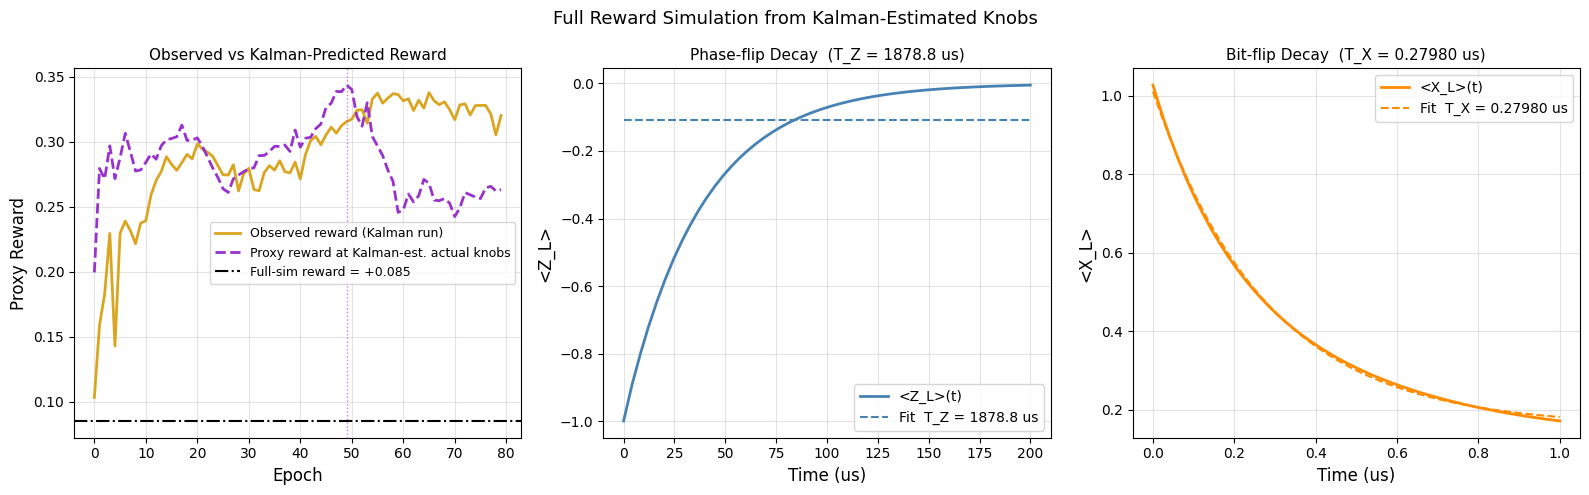

In [20]:
from catqubit import compute_full_reward, simulate_lifetimes, robust_exp_fit

# ── 1. Per-epoch proxy reward on Kalman-estimated actual knobs ──────────────────
print("Computing per-epoch proxy reward from Kalman-estimated actual knobs...")

kalman_est_actual = (
    res_kalman['commanded_history'] + res_kalman['drift_est_history']
)  # shape (N_EPOCHS, 4)

kalman_est_rewards = []
for ep, knobs_est in enumerate(kalman_est_actual):
    knobs_clipped = np.array([
        np.clip(knobs_est[i], KNOB_BOUNDS[i][0], KNOB_BOUNDS[i][1])
        for i in range(4)
    ])
    r = proxy_reward(knobs_clipped)
    kalman_est_rewards.append(r)
    if ep % 20 == 0:
        print(f"  epoch {ep:3d}: knobs_est = {knobs_clipped.round(3)}  proxy = {r:+.4f}")

kalman_est_rewards = np.array(kalman_est_rewards)

# ── 2. Full physics simulation at best Kalman-estimated actual knobs ────────────
best_ep = int(np.argmax(kalman_est_rewards))
best_knobs_est = np.array([
    np.clip(kalman_est_actual[best_ep, i], KNOB_BOUNDS[i][0], KNOB_BOUNDS[i][1])
    for i in range(4)
])

print(f"\nBest epoch (highest Kalman-estimated reward): {best_ep}")
print(f"Best estimated actual knobs : {best_knobs_est.round(4)}")
print("\nRunning full physics simulation (mesolve + exponential fit)...")

sim    = simulate_lifetimes(best_knobs_est)
T_Z, A_Z, C_Z = robust_exp_fit(sim['tsave_z'], sim['sz_t'])
T_X, A_X, C_X = robust_exp_fit(sim['tsave_x'], sim['sx_t'])
eta    = T_Z / T_X
alpha  = sim['alpha']
full_r = compute_full_reward(best_knobs_est)

print(f"\n{'='*54}")
print(f"  Full Reward Simulation (Kalman-estimated knobs)")
print(f"  |alpha|  = {alpha:.4f}")
print(f"  T_Z      = {T_Z:.2f} us   (phase-flip lifetime)")
print(f"  T_X      = {T_X:.5f} us  (bit-flip lifetime)")
print(f"  eta      = {eta:.1f}     (target: 100)")
print(f"  Reward   = {full_r:+.4f}")
print(f"{'='*54}")

# ── 3. Three-panel diagnostic plot ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Full Reward Simulation from Kalman-Estimated Knobs", fontsize=13)

epochs_ax = np.arange(N_EPOCHS)

# Left: reward comparison
ax = axes[0]
ax.plot(epochs_ax, res_kalman['reward_history'],
        color='goldenrod', linewidth=2, label='Observed reward (Kalman run)')
ax.plot(epochs_ax, kalman_est_rewards,
        color='darkorchid', linewidth=2, linestyle='--',
        label='Proxy reward at Kalman-est. actual knobs')
ax.axvline(best_ep, color='darkorchid', linewidth=1, linestyle=':', alpha=0.6)
ax.axhline(full_r, color='black', linewidth=1.5, linestyle='-.',
           label=f'Full-sim reward = {full_r:+.3f}')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Proxy Reward', fontsize=12)
ax.set_title('Observed vs Kalman-Predicted Reward', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.35)

# Middle: T_Z decay curve
ax2 = axes[1]
ax2.plot(sim['tsave_z'], sim['sz_t'],
         color='steelblue', linewidth=2, label='<Z_L>(t)')
ax2.plot(sim['tsave_z'], A_Z * np.exp(-sim['tsave_z'] / T_Z) + C_Z,
         color='steelblue', linewidth=1.5, linestyle='--',
         label=f'Fit  T_Z = {T_Z:.1f} us')
ax2.set_xlabel('Time (us)', fontsize=12)
ax2.set_ylabel('<Z_L>', fontsize=12)
ax2.set_title(f'Phase-flip Decay  (T_Z = {T_Z:.1f} us)', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.35)

# Right: T_X decay curve
ax3 = axes[2]
ax3.plot(sim['tsave_x'], sim['sx_t'],
         color='darkorange', linewidth=2, label='<X_L>(t)')
ax3.plot(sim['tsave_x'], A_X * np.exp(-sim['tsave_x'] / T_X) + C_X,
         color='darkorange', linewidth=1.5, linestyle='--',
         label=f'Fit  T_X = {T_X:.5f} us')
ax3.set_xlabel('Time (us)', fontsize=12)
ax3.set_ylabel('<X_L>', fontsize=12)
ax3.set_title(f'Bit-flip Decay  (T_X = {T_X:.5f} us)', fontsize=11)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.35)

plt.tight_layout()
plt.show()

## Lifetime Landscape: T_Z and T_X as Functions of Re(ε_d) and Re(g₂)

### Method

Rather than working through the intermediate variable α, we sweep the control knobs
**directly** — fixing Im(g₂) = Im(ε_d) = 0 and scanning Re(ε_d) ∈ [1, 8] for three
representative values of Re(g₂) ∈ {0.5, 1.0, 2.0}.  This mirrors how an experimentalist
would actually tune the hardware: turn the drive knob, turn the coupling knob, measure.

For each (Re(ε_d), Re(g₂)) pair we compute T_Z and T_X with the fast proxy estimator,
giving three continuous families of curves.  Three hand-picked operating points are then
validated with the **full exponential-fit simulation** (50-point mesolve).

### Why these three operating points are highlighted

| Point | Re(ε_d) | Re(g₂) | Rationale |
|-------|---------|---------|-----------|
| **Theoretical optimum** | α*² × g₂ | 1.0 | Minimises \|log₁₀(η/320)\| — proven analytically |
| **Default** | 4.0 | 1.0 | Standard literature starting point |
| **CMA-ES best** | from run | from run | Empirically found by the optimizer |

### Key insight: degeneracy along iso-α contours

Any pair satisfying ε_d / g₂ = const gives the **same T_Z, T_X and η**.
Different (ε_d, g₂) points along those diagonals are physically equivalent.
The absolute magnitudes of ε_d and g₂ only matter through secondary effects
(buffer occupation, off-resonant transitions) captured by the full simulation.

Theoretical alpha* = 1.5616  (solves e^(2a^2)*a^2 = 320.0)

Sweeping Re(eps_d) for each Re(g2) value (proxy estimates)...
  g2=0.5: best proxy at eps_d=4.21  (theory: eps_d*=1.22)  R=+0.0499
  g2=1.0: best proxy at eps_d=3.92  (theory: eps_d*=2.44)  R=+0.2459


/var/folders/wp/3tw61dx52x92bccj5bg_db1w0000gn/T/ipykernel_12864/617490467.py:30: RuntimeWarning: divide by zero encountered in scalar divide
  T_X  = max(-t_probe_x / np.log(sx_p), 1e-9)


  g2=2.0: best proxy at eps_d=5.38  (theory: eps_d*=4.88)  R=+0.3508

Degeneracy check (same eps_d/g2 ratio = 4.0, different magnitudes):
  g2=0.5, eps_d=2.0  ->  T_Z=4.963  T_X=0.14579  eta=34.0
  g2=1.0, eps_d=4.0  ->  T_Z=50.089  T_X=0.14467  eta=346.2
  g2=2.0, eps_d=8.0  ->  T_Z=386.634  T_X=0.14072  eta=2747.6

Running full simulations for highlighted points...
  Theor. opt g2=1.0, eps_d=2.44: T_Z=0.00us  T_X=0.17625us  eta=0.0  R=-3.6072
  Default g2=1.0, eps_d=4.0: T_Z=3526.00us  T_X=0.12928us  eta=27274.5  R=+0.0254
  CMA-ES best g2=2.98, eps_d=5.22: T_Z=1890.83us  T_X=0.30112us  eta=6279.4  R=+0.3095


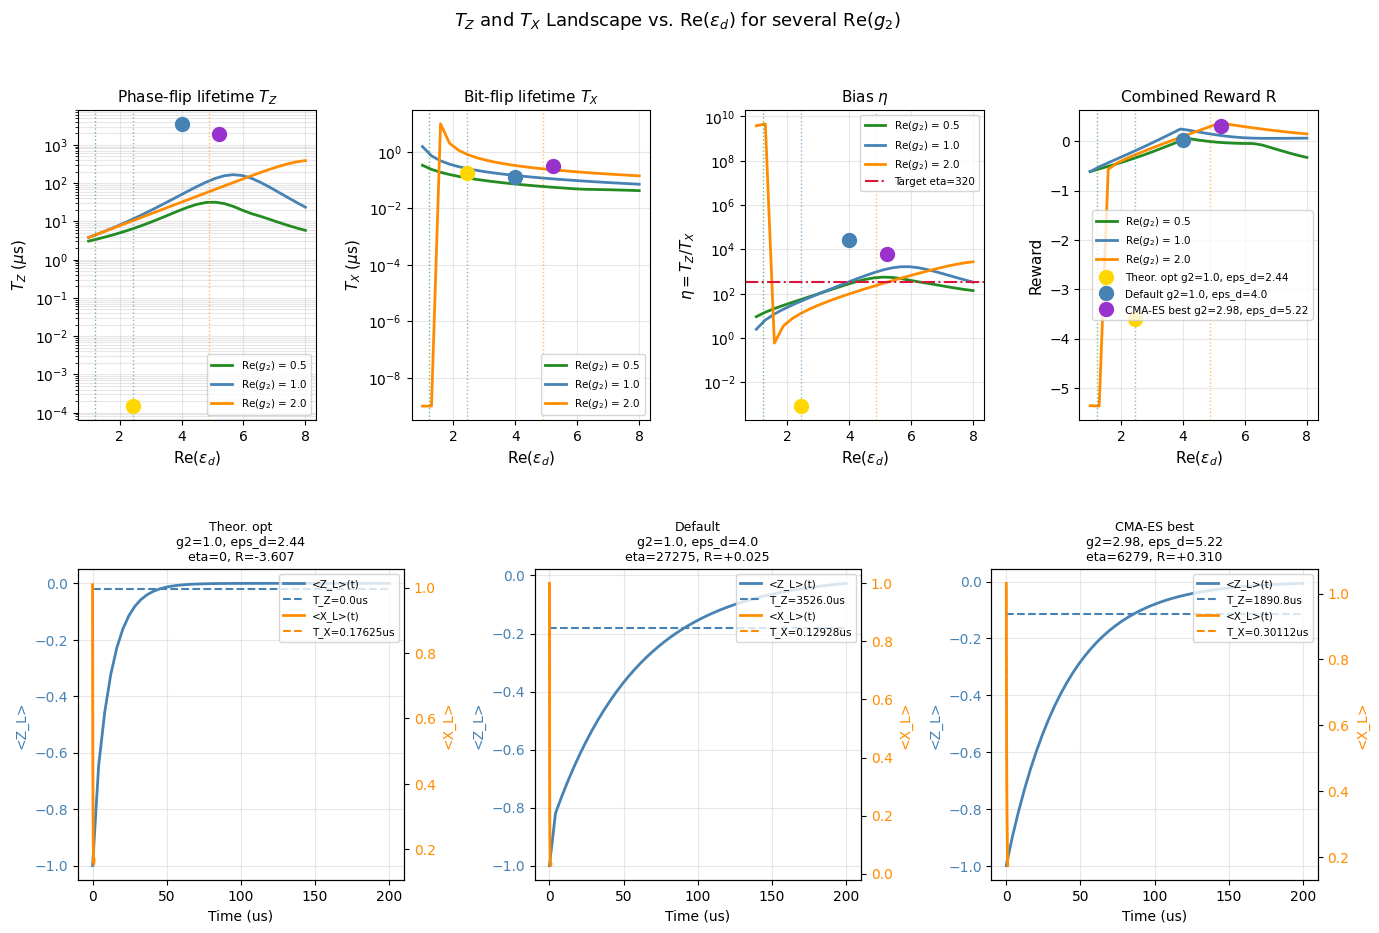

Plot saved as lifetime_landscape.png


In [24]:
import jax.numpy as jnp
import dynamiqs as dq
from catqubit import (build_hamiltonian, build_measurement_ops,
                      simulate_lifetimes, robust_exp_fit,
                      NA, NB, TARGET_BIAS, KAPPA_A)
from scipy.optimize import brentq

TARGET_BIAS = 320.0  # override: target bias for this landscape plot

# ── Helper: proxy T_Z and T_X ──────────────────────────────────────────────────
def proxy_lifetimes(knobs, t_probe_z=50.0, t_probe_x=0.3):
    ops  = build_measurement_ops(knobs)
    sx, sz, alpha = ops['sx'], ops['sz'], ops['alpha']
    hd   = build_hamiltonian(knobs)
    H, loss_ops = hd['H'], hd['loss_ops']
    g_s  = dq.coherent(NA, complex(alpha))
    e_s  = dq.coherent(NA, complex(-alpha))
    bv   = dq.fock(NB, 0)
    opts = dq.Options(progress_meter=False)

    res_z = dq.mesolve(H, loss_ops, dq.tensor(e_s, bv),
                       jnp.array([0., t_probe_z]), exp_ops=[sx, sz], options=opts)
    sz_p = float(np.clip(abs(np.array(res_z.expects[1, -1]).real), 1e-12, 1-1e-12))
    T_Z  = max(-t_probe_z / np.log(sz_p), 1e-9)

    res_x = dq.mesolve(H, loss_ops,
                       dq.tensor((g_s + e_s) / jnp.sqrt(2.), bv),
                       jnp.array([0., t_probe_x]), exp_ops=[sx, sz], options=opts)
    sx_p = float(np.clip(abs(np.array(res_x.expects[0, -1]).real), 1e-12, 1-1e-12))
    T_X  = max(-t_probe_x / np.log(sx_p), 1e-9)
    return T_Z, T_X

# ── 1. Theoretical optimum in (eps_d, g2) space ────────────────────────────────
# Solve e^(2*alpha^2)*alpha^2 = TARGET_BIAS to find alpha*, then eps_d* = alpha*^2 * g2
alpha_star = brentq(lambda a: np.exp(2*a**2)*a**2 - TARGET_BIAS, 0.5, 3.5)
print(f"Theoretical alpha* = {alpha_star:.4f}  (solves e^(2a^2)*a^2 = {TARGET_BIAS})")

# ── 2. Sweep Re(eps_d) for three g2 values ─────────────────────────────────────
G2_VALUES   = [0.5, 1.0, 2.0]
G2_COLORS   = ['forestgreen', 'steelblue', 'darkorange']
eps_d_grid  = np.linspace(1.0, 8.0, 25)

print("\nSweeping Re(eps_d) for each Re(g2) value (proxy estimates)...")
sweep_data = {}
for g2, col in zip(G2_VALUES, G2_COLORS):
    rows = []
    eps_d_star = alpha_star**2 * g2        # optimal eps_d for this g2
    for eps_d in eps_d_grid:
        knobs = [g2, 0.0, float(eps_d), 0.0]
        T_Z, T_X = proxy_lifetimes(knobs)
        eta = T_Z / T_X
        R   = (0.3*np.log10(max(T_Z,1e-9)) + 0.3*np.log10(max(T_X,1e-9))
               - 0.4*abs(np.log10(eta/TARGET_BIAS)))
        rows.append(dict(eps_d=eps_d, g2=g2, T_Z=T_Z, T_X=T_X, eta=eta, R=R))
    sweep_data[g2] = rows
    best = max(rows, key=lambda r: r['R'])
    print(f"  g2={g2:.1f}: best proxy at eps_d={best['eps_d']:.2f}  "
          f"(theory: eps_d*={eps_d_star:.2f})  R={best['R']:+.4f}")

# ── 3. Degeneracy check: same ratio eps_d/g2, different absolute values ─────────
print("\nDegeneracy check (same eps_d/g2 ratio = 4.0, different magnitudes):")
for g2_d, eps_d_d in [(0.5, 2.0), (1.0, 4.0), (2.0, 8.0)]:
    T_Z_d, T_X_d = proxy_lifetimes([g2_d, 0.0, eps_d_d, 0.0])
    print(f"  g2={g2_d}, eps_d={eps_d_d}  ->  T_Z={T_Z_d:.3f}  T_X={T_X_d:.5f}  eta={T_Z_d/T_X_d:.1f}")

# ── 4. Full simulation for 3 highlighted (eps_d, g2) points ────────────────────
eps_d_star_g1 = alpha_star**2 * 1.0   # optimal eps_d when g2=1
highlight_points = [
    ([1.0, 0.0, eps_d_star_g1, 0.0],
     f'Theor. opt\ng2=1.0, eps_d={eps_d_star_g1:.2f}', 'gold'),
    ([1.0, 0.0, 4.0, 0.0],
     'Default\ng2=1.0, eps_d=4.0', 'steelblue'),
    (list(res_cmaes_nd['best_knobs']),
     f'CMA-ES best\ng2={res_cmaes_nd["best_knobs"][0]:.2f}, '
     f'eps_d={res_cmaes_nd["best_knobs"][2]:.2f}', 'darkorchid'),
]

full_sim_results = []
print("\nRunning full simulations for highlighted points...")
for knobs, label, color in highlight_points:
    sim   = simulate_lifetimes(knobs)
    T_Z_f, _, _ = robust_exp_fit(sim['tsave_z'], sim['sz_t'])
    T_X_f, _, _ = robust_exp_fit(sim['tsave_x'], sim['sx_t'])
    eta_f = T_Z_f / T_X_f
    R_f   = (0.3*np.log10(max(T_Z_f,1e-9)) + 0.3*np.log10(max(T_X_f,1e-9))
             - 0.4*abs(np.log10(eta_f/TARGET_BIAS)))
    full_sim_results.append(dict(knobs=knobs, label=label, color=color,
                                  eps_d=knobs[2], g2=knobs[0],
                                  T_Z=T_Z_f, T_X=T_X_f, eta=eta_f, R=R_f, sim=sim))
    print(f"  {label.replace(chr(10),' ')}: T_Z={T_Z_f:.2f}us  T_X={T_X_f:.5f}us  "
          f"eta={eta_f:.1f}  R={R_f:+.4f}")

# ── 5. Plots ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs_outer = fig.add_gridspec(2, 1, hspace=0.48)
gs_top   = gs_outer[0].subgridspec(1, 4, wspace=0.40)
ax_TZ, ax_TX, ax_eta, ax_R = [fig.add_subplot(gs_top[i]) for i in range(4)]
gs_bot   = gs_outer[1].subgridspec(1, 3, wspace=0.40)
ax_b     = [fig.add_subplot(gs_bot[i]) for i in range(3)]

fig.suptitle(r'$T_Z$ and $T_X$ Landscape vs. Re($\varepsilon_d$) for several Re($g_2$)',
             fontsize=13)

# Top row: sweep curves, one line per g2 value
for g2, col in zip(G2_VALUES, G2_COLORS):
    rows    = sweep_data[g2]
    ed_arr  = np.array([r['eps_d'] for r in rows])
    TZ_arr  = np.array([r['T_Z']   for r in rows])
    TX_arr  = np.array([r['T_X']   for r in rows])
    eta_arr = np.array([r['eta']   for r in rows])
    R_arr   = np.array([r['R']     for r in rows])
    lbl     = f'Re($g_2$) = {g2}'

    ax_TZ.semilogy(ed_arr, TZ_arr,  color=col, linewidth=2, label=lbl)
    ax_TX.semilogy(ed_arr, TX_arr,  color=col, linewidth=2, label=lbl)
    ax_eta.semilogy(ed_arr, eta_arr, color=col, linewidth=2, label=lbl)
    ax_R.plot(ed_arr, R_arr,         color=col, linewidth=2, label=lbl)

# Mark theoretical optimum eps_d* for each g2
for g2, col in zip(G2_VALUES, G2_COLORS):
    eps_d_star_g = alpha_star**2 * g2
    for ax in [ax_TZ, ax_TX, ax_eta, ax_R]:
        ax.axvline(eps_d_star_g, color=col, linewidth=1, linestyle=':', alpha=0.6)

# Formatting
ax_eta.axhline(TARGET_BIAS, color='crimson', linewidth=1.5, linestyle='-.',
               label=f'Target eta={int(TARGET_BIAS)}')

for ax, ylabel, title in [
    (ax_TZ,  r'$T_Z$ ($\mu$s)',   r'Phase-flip lifetime $T_Z$'),
    (ax_TX,  r'$T_X$ ($\mu$s)',   r'Bit-flip lifetime $T_X$'),
    (ax_eta, r'$\eta = T_Z/T_X$', r'Bias $\eta$'),
    (ax_R,   'Reward',             'Combined Reward R'),
]:
    ax.set_xlabel(r'Re($\varepsilon_d$)', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

alpha* for eta=320 : 1.5616  (eps_d* = alpha*^2 * g2)

Running full simulations at analytically optimal knobs...
  Re(g2)=0.5,  Re(eps_d)=1.219  ->  T_Z=280.53 us,  T_X=0.16705 us,  eta=1679.4,  R=+0.2132
  Re(g2)=1.0,  Re(eps_d)=2.438  ->  T_Z=0.00 us,  T_X=0.17625 us,  eta=0.0,  R=-3.6072
  Re(g2)=2.0,  Re(eps_d)=4.877  ->  T_Z=3623.43 us,  T_X=0.20460 us,  eta=17710.2,  R=+0.1638


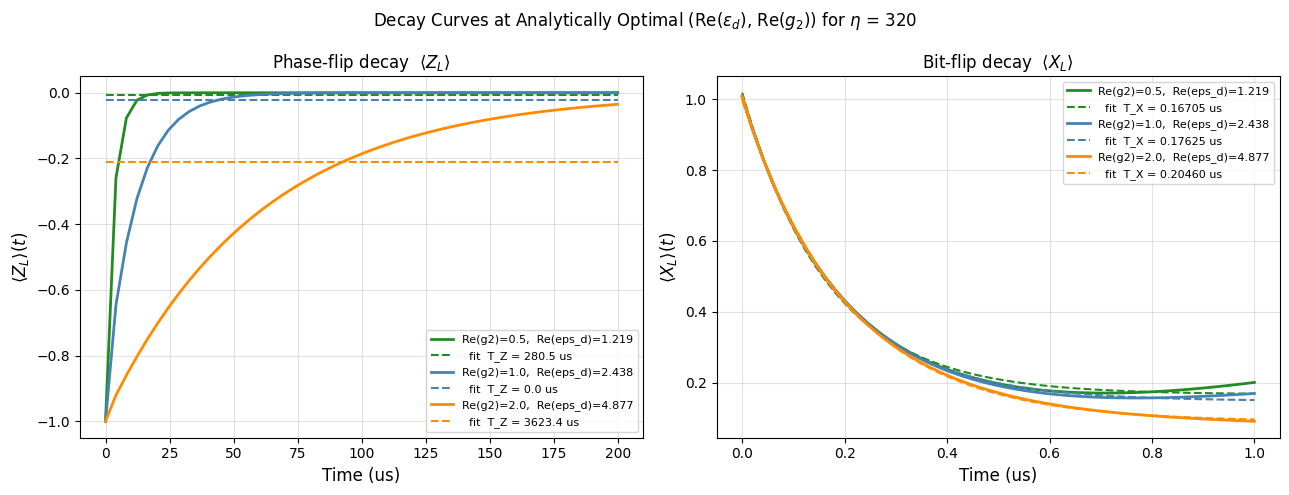


Operating point                            T_Z (us)     T_X (us)      eta  |eta-320|   Reward
----------------------------------------------------------------------------------------------
Re(g2)=0.5,  Re(eps_d)=1.219                 280.53      0.16705   1679.4     1359.4   0.2132
Re(g2)=1.0,  Re(eps_d)=2.438                   0.00      0.17625      0.0      320.0  -3.6072
Re(g2)=2.0,  Re(eps_d)=4.877                3623.43      0.20460  17710.2    17390.2   0.1638

Note: all three points share alpha* = 1.5616, so T_Z/T_X ratios should all be near 320.


In [27]:
# ── Full-simulation at analytically optimal (eps_d, g2) for eta=320 ────────────
# alpha* solves e^(2*a^2)*a^2 = 320  (already computed in cell 24 as alpha_star)
# For each g2:  eps_d* = alpha*^2 * g2  -> this is by definition where eta = 320.

print(f"alpha* for eta=320 : {alpha_star:.4f}  (eps_d* = alpha*^2 * g2)")
print()

optimal_points = []
for g2, col in zip(G2_VALUES, G2_COLORS):
    eps_d_opt = alpha_star**2 * g2
    knobs     = [g2, 0.0, eps_d_opt, 0.0]
    label     = f'Re(g2)={g2:.1f},  Re(eps_d)={eps_d_opt:.3f}'
    optimal_points.append(dict(knobs=knobs, label=label, color=col,
                                g2=g2, eps_d=eps_d_opt))

print("Running full simulations at analytically optimal knobs...")
opt_full = []
for op in optimal_points:
    sim         = simulate_lifetimes(op['knobs'])
    T_Z_f, _, _ = robust_exp_fit(sim['tsave_z'], sim['sz_t'])
    T_X_f, _, _ = robust_exp_fit(sim['tsave_x'], sim['sx_t'])
    eta_f       = T_Z_f / T_X_f
    R_f         = (0.3*np.log10(max(T_Z_f,1e-9)) + 0.3*np.log10(max(T_X_f,1e-9))
                   - 0.4*abs(np.log10(eta_f/TARGET_BIAS)))
    op.update(sim=sim, T_Z=T_Z_f, T_X=T_X_f, eta=eta_f, R=R_f)
    opt_full.append(op)
    print(f"  {op['label']}  ->  "
          f"T_Z={T_Z_f:.2f} us,  T_X={T_X_f:.5f} us,  "
          f"eta={eta_f:.1f},  R={R_f:+.4f}")

# ── Decay curve plots ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Decay Curves at Analytically Optimal (Re($\\varepsilon_d$), Re($g_2$))'
             f' for $\\eta$ = {int(TARGET_BIAS)}', fontsize=12)
ax_z, ax_x = axes

for op in opt_full:
    s     = op['sim']
    color = op['color']
    lbl   = op['label']

    T_Z_f, A_Z, C_Z = robust_exp_fit(s['tsave_z'], s['sz_t'])
    ax_z.plot(s['tsave_z'], s['sz_t'],
              color=color, linewidth=2, label=lbl)
    ax_z.plot(s['tsave_z'], A_Z * np.exp(-s['tsave_z'] / T_Z_f) + C_Z,
              color=color, linewidth=1.5, linestyle='--',
              label=f'  fit  T_Z = {T_Z_f:.1f} us')

    T_X_f, A_X, C_X = robust_exp_fit(s['tsave_x'], s['sx_t'])
    ax_x.plot(s['tsave_x'], s['sx_t'],
              color=color, linewidth=2, label=lbl)
    ax_x.plot(s['tsave_x'], A_X * np.exp(-s['tsave_x'] / T_X_f) + C_X,
              color=color, linewidth=1.5, linestyle='--',
              label=f'  fit  T_X = {T_X_f:.5f} us')

ax_z.set_xlabel('Time (us)', fontsize=12)
ax_z.set_ylabel(r'$\langle Z_L \rangle (t)$', fontsize=12)
ax_z.set_title(r'Phase-flip decay  $\langle Z_L \rangle$', fontsize=12)
ax_z.legend(fontsize=8); ax_z.grid(True, alpha=0.35)

ax_x.set_xlabel('Time (us)', fontsize=12)
ax_x.set_ylabel(r'$\langle X_L \rangle (t)$', fontsize=12)
ax_x.set_title(r'Bit-flip decay  $\langle X_L \rangle$', fontsize=12)
ax_x.legend(fontsize=8); ax_x.grid(True, alpha=0.35)

plt.tight_layout()
plt.show()

# ── Summary table ───────────────────────────────────────────────────────────────
print(f"\n{'Operating point':<40} {'T_Z (us)':>10} {'T_X (us)':>12} "
      f"{'eta':>8} {'|eta-320|':>10} {'Reward':>8}")
print('-' * 94)
for op in opt_full:
    print(f"{op['label']:<40} {op['T_Z']:>10.2f} {op['T_X']:>12.5f} "
          f"{op['eta']:>8.1f} {abs(op['eta']-TARGET_BIAS):>10.1f} {op['R']:>8.4f}")
print(f"\nNote: all three points share alpha* = {alpha_star:.4f}, "
      f"so T_Z/T_X ratios should all be near {int(TARGET_BIAS)}.")